In [1]:
import pandas as pd
import numpy as np
import scipy as sp
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
matplotlib.rcParams["ps.useafm"] = True
matplotlib.rcParams["pdf.use14corefonts"] = True
import seaborn as sns
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"
%matplotlib inline
import pandas as pd
plt.rcParams['font.size'] = 8

In [2]:
catalog = pd.read_csv('/rawdata/gene_catalog.csv')

In [3]:
def get_results(date='260408', cohort='AA', predictdb='gala_AA', pvals = ['p1_base', 'p1_alt', 'p2_base', 'p2_alt']):
    df = pd.read_csv('/home/yxy1313/SKATproject/PrediXSKAT_figs/data/260405_Results/'+date+'_'+cohort+'_'+predictdb+'.csv', header=None)
    df = df[df.columns[2:]]
    df.columns = ['gene_symbol', 'gene_name', 'nvars']+pvals
    df = catalog.loc[catalog['source']==predictdb].merge(df, how='right', on=['gene_symbol', 'gene_name'])
    df[pvals] = (
        df[pvals]
        .astype(float)
        .replace(2.0, np.nan)
        .replace(np.inf, np.nan)
        .fillna(1)
    )
    df[pvals] = df[pvals].mask(df[pvals] <= 0, 1e-8)
    for col in pvals:
        df['log_'+col] = np.log10(df[col]) * -1
    return df

In [4]:
gvc=['SORT1', 'CR1', 'ADAM17', 'PRKD3', 'NCK2', 'BIN1', 'WDR12', 'INPP5D', 'MME', 'IDUA', 'CLNK', 'RHOH', 'ANKH', 'COX7C', 'TNIP1', 'RASGEF1C', 'HLA-DQA1', 'UNC5CL', 'TREM2', 'TREML2', 'CD2AP', 'HS3ST5', 'UMAD1', 'ICA1', 'TMEM106B', 'JAZF1', 'EPDR1', 'SEC61G', 'SPDYE3', 'EPHA1', 'CTSB', 'PTK2B', 'CLU', 'SHARPIN', 'ABCA1', 'USP6NL', 'ANK3', 'TSPAN14', 'BLNK', 'PLEKHA1', 'SPI1', 'MS4A4A', 'EED', 'SORL1', 'TPCN1', 'FERMT2', 'SLC24A4', 'SPPL2A', 'MINDY2', 'APH1B', 'SNX1', 'CTSH', 'DOC2A', 'BCKDK', 'IL34', 'MAF', 'PLCG2', 'FOXF1', 'PRDM7', 'WDR81', 'SCIMP', 'MYO15A', 'GRN', 'WNT3', 'ABI3', 'TSPOAP1', 'ACE', 'ABCA7', 'KLF16', 'SIGLEC11', 'LILRB2', 'RBCK1', 'CASS4', 'SLC2A4RG', 'APP', 'ADAMTS1', 'ABCA7', 'ABI3', 'APOE', 'APP', 'APBB3', 'BIN1', 'EPHA1', 'CASP7', 'CR1', 'MS4A6A', 'PILRA', 'PLCG2', 'PSEN1', 'PSEN2', 'ADAM10', 'RIN3', 'SORL1', 'SPI1', 'TREM2', 'PICALM']

In [5]:
import matplotlib.patheffects as pe
from adjustText import adjust_text

def scatters(df, x_col='log_p1_base', y_col='log_p1_alt', label_col='gene_name', top_n_deviated=30, threshold=5, gene_list=gvc,
    figsize=(6, 6), point_color='blue', point_alpha=0.8, point_size=18, label_fontsize=6,
    title='Scatterplot', xlabel='Unmodified SKAT -log10pval', ylabel='PrediXSKAT -log10pval', saveas=None, ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=figsize)
    else:
        fig = ax.figure 
    x = df[x_col].values
    y = df[y_col].values
    labels = df[label_col].values
    ax.scatter(x, y, s=point_size, alpha=point_alpha, color=point_color, linewidths=0)
    lims = [min(ax.get_xlim()[0], ax.get_ylim()[0]), max(ax.get_xlim()[1], ax.get_ylim()[1])]
    ax.plot(lims, lims, 'r--', linewidth=0.5, alpha=0.5, zorder=0, label='y = x')
    ax.set_xlim(lims)
    ax.set_ylim(lims)

    label_indices = set()
    if top_n_deviated and top_n_deviated > 0:
        distances = np.abs(y - x)
        deviated_idx = np.argsort(distances)[-top_n_deviated:]
        label_indices.update(deviated_idx.tolist())
    if threshold is not None:
        label_indices.update(np.where(x > threshold)[0].tolist())
        label_indices.update(np.where(y > threshold)[0].tolist())
    if gene_list is not None:
        gene_mask = df[label_col].isin(gene_list).values
        label_indices.update(np.where(gene_mask)[0].tolist())

    gene_set = set(gene_list) if gene_list is not None else set()

    texts = []
    for i in label_indices:
        xi, yi, lab = x[i], y[i], labels[i]
        text_color = 'green' if lab in gene_set else 'black'
        text_obj = ax.text(xi, yi, lab, fontsize=label_fontsize, color=text_color, weight='normal', zorder=1000 if lab in gene_set else 100,
            path_effects=[pe.withStroke(linewidth=2, foreground='white')])
        texts.append(text_obj)
    if texts:
        adjust_text(texts, arrowprops=dict(arrowstyle='->', color='gray', lw=0.5, alpha=0.7))

    ax.set_xlabel(xlabel or x_col, fontsize=8)
    ax.set_ylabel(ylabel or y_col, fontsize=8)
    ax.set_title(title, fontsize=10)
    ax.grid(True, which='both', color='gray', linestyle='--', linewidth=0.2, alpha=0.4, zorder=0)
    ax.set_axisbelow(True)
    plt.tight_layout()
    plt.show()
    if saveas is not None:
        fig.savefig(saveas+'.pdf', format="pdf", bbox_inches="tight")
    return fig, ax
    

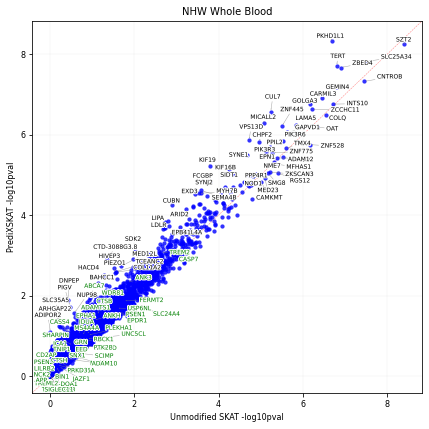

(<Figure size 432x432 with 1 Axes>,
 <AxesSubplot:title={'center':'NHW Whole Blood'}, xlabel='Unmodified SKAT -log10pval', ylabel='PrediXSKAT -log10pval'>)

In [6]:
df = get_results(cohort='NHW', predictdb='gtex_WB')
scatters(df, x_col='log_p1_base', y_col='log_p1_alt', label_col='gene_name', gene_list=gvc, top_n_deviated=30, threshold=5, 
                           title='NHW Whole Blood', xlabel='Unmodified SKAT -log10pval', ylabel='PrediXSKAT -log10pval', saveas='fig8')

In [8]:
from qmplot import qqplot

In [17]:
df['p1_base'].values

array([0.64199029, 0.3476747 , 0.67429028, ..., 0.71918045, 0.37734754,
       0.30002245])

<AxesSubplot:title={'center':'NHW Whole Blood \n Unmodified SKAT $(\\lambda = 1.198)$'}, xlabel='$Expected(-log_{10}{(P)})$', ylabel='$Observed(-log_{10}{(P)})$'>

<AxesSubplot:title={'center':'PrediXSKAT $(\\lambda = 1.348)$'}, xlabel='$Expected(-log_{10}{(P)})$', ylabel='$Observed(-log_{10}{(P)})$'>

Text(-0.1, 1.05, 'a')

Text(-0.1, 1.05, 'b')

findfont: Font family ['sans-serif'] not found. Falling back to Helvetica.
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Lucida Sans, DejaVu Sans, Lucida Grande, Verdana
findfont: Font family ['sans-serif'] not found. Falling back to Helvetica.
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Lucida Sans, DejaVu Sans, Lucida Grande, Verdana
findfont: Font family ['sans-serif'] not found. Falling back to Helvetica.
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Lucida Sans, DejaVu Sans, Lucida Grande, Verdana


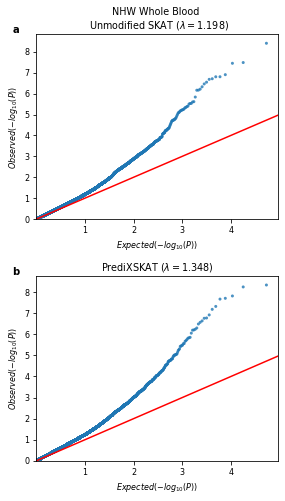

In [61]:
fig, axes = plt.subplots(2, 1, figsize=(4, 7))
qqplot(np.concatenate([df['p1_base'].values, np.random.uniform(0.005, 1, 20000), np.random.uniform(0.0001, 0.005, 200)]), marker='.', ax=axes[0], title='NHW Whole Blood \n Unmodified SKAT ')
qqplot(np.concatenate([df['p1_alt'].values, np.random.uniform(0.005, 1, 20000), np.random.uniform(0.0001, 0.005, 200)]), marker='.', ax=axes[1], title='PrediXSKAT ')
for ax, label in zip(axes, ['a', 'b']):
    ax.text(-0.1, 1.05, label, transform=ax.transAxes,
            fontsize=10, fontweight='bold', va='top')
plt.tight_layout()
plt.savefig("Fig_S2.pdf")

In [24]:
df.loc[df['gene_name']=='EPPK1']

,gene_symbol,min_pos,max_pos,var_count,chrom,gene,gene_name,source,nvars,p1_base,p1_alt,p2_base,p2_alt,log_p1_base,log_p1_alt,log_p2_base,log_p2_alt
9750,ENSG00000261150,143857991.0,143873232.0,1672.0,8.0,ENSG00000261150.2,EPPK1,gala_AA,181,0.031922,0.000209,0.03163,0.000204,1.495909,3.679439,1.499907,3.689515


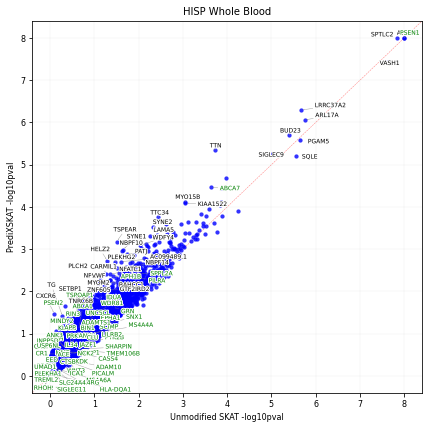

(<Figure size 432x432 with 1 Axes>,
 <AxesSubplot:title={'center':'HISP Whole Blood'}, xlabel='Unmodified SKAT -log10pval', ylabel='PrediXSKAT -log10pval'>)

In [25]:
df = get_results(cohort='HISP', predictdb='gala_PR')
scatters(df, x_col='log_p1_base', y_col='log_p1_alt', label_col='gene_name', gene_list=gvc, top_n_deviated=30, threshold=5, 
                           title='HISP Whole Blood', xlabel='Unmodified SKAT -log10pval', ylabel='PrediXSKAT -log10pval', saveas='fig10')

In [47]:
df = get_results(cohort='NHW', predictdb='gtex_WB')
df1 = pd.read_csv('/home/yxy1313/SKATproject/PrediXSKAT_figs/data/260405_Results/260412_hiphred_NHW_gtex_WB.csv', header=None)
df1 = df1[df1.columns[2:]].dropna()
df1.columns = ['gene_symbol', 'gene_name', 'nvars', 'p1_base', 'p1_alt']
df1 = catalog.loc[catalog['source']=='gtex_WB'].merge(df1, how='right', on=['gene_symbol', 'gene_name'])
pvals = ['p1_base', 'p1_alt']
df1[pvals] = (df1[pvals].astype(float).replace(2.0, np.nan).replace(np.inf, np.nan).fillna(1))
df1[pvals] = df1[pvals].mask(df1[pvals] <= 0, 1e-8)
for col in pvals:
    df1['log_'+col] = np.log10(df1[col]) * -1

dfa = get_results(cohort='AA', predictdb='gala_AA')
df2 = pd.read_csv('/home/yxy1313/SKATproject/PrediXSKAT_figs/data/260405_Results/260412_hiphred_AA_gala_AA.csv', header=None)
df2 = df2[df2.columns[2:]].dropna()
df2.columns = ['gene_symbol', 'gene_name', 'nvars', 'p1_base', 'p1_alt']
df2 = catalog.loc[catalog['source']=='gala_AA'].merge(df2, how='right', on=['gene_symbol', 'gene_name'])
pvals = ['p1_base', 'p1_alt']
df2[pvals] = (df2[pvals].astype(float).replace(2.0, np.nan).replace(np.inf, np.nan).fillna(1))
df2[pvals] = df2[pvals].mask(df2[pvals] <= 0, 1e-8)
for col in pvals:
    df2['log_'+col] = np.log10(df2[col]) * -1

In [51]:
df1 = df1.merge(df, how='inner', on=['gene_symbol', 'gene', 'gene_name'], suffixes=['hiphred', 'all'])
df2 = df2.merge(dfa, how='inner', on=['gene_symbol', 'gene', 'gene_name'], suffixes=['hiphred', 'all'])

In [52]:
df2

,gene_symbol,min_poshiphred,max_poshiphred,var_counthiphred,chromhiphred,gene,gene_name,sourcehiphred,nvarshiphred,p1_basehiphred,...,sourceall,nvarsall,p1_baseall,p1_altall,p2_base,p2_alt,log_p1_baseall,log_p1_altall,log_p2_base,log_p2_alt
0,ENSG00000014257,132317463.0,132367800.0,94.0,3.0,ENSG00000014257.16,ACPP,gala_AA,3,0.578777,...,gala_AA,4,0.305481,0.253065,0.304390,0.252039,0.515015,0.596767,0.516569,0.598532
1,ENSG00000014824,41990670.0,42086097.0,95.0,4.0,ENSG00000014824.14,SLC30A9,gala_AA,2,0.920410,...,gala_AA,5,0.307416,0.330139,0.236760,0.241778,0.512274,0.481303,0.625691,0.616583
2,ENSG00000014914,149928893.0,149936632.0,149.0,1.0,ENSG00000014914.21,MTMR11,gala_AA,5,0.398155,...,gala_AA,6,0.464711,0.248287,0.464786,0.248384,0.332817,0.605045,0.332747,0.604876
3,ENSG00000014919,99713417.0,99732023.0,88.0,10.0,ENSG00000014919.12,COX15,gala_AA,1,0.933480,...,gala_AA,2,0.879974,0.463703,0.879145,0.463908,0.055530,0.333760,0.055940,0.333568
4,ENSG00000015133,91272666.0,91417685.0,555.0,14.0,ENSG00000015133.19,CCDC88C,gala_AA,24,0.562200,...,gala_AA,41,0.567732,0.128956,0.556640,0.131841,0.245857,0.889558,0.254425,0.879949
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8268,ENSG00000204344,31972415.0,31981039.0,55.0,6.0,ENSG00000204344.14,STK19,gala_AA,2,0.552297,...,gala_AA,2,0.552297,0.548413,0.538898,0.526111,0.257827,0.260893,0.268494,0.278923
8269,ENSG00000204345,74580006.0,74592187.0,44.0,17.0,ENSG00000204345.1,CD300LD,gala_AA,1,0.756621,...,gala_AA,1,0.756621,0.633732,0.773962,0.650011,0.121122,0.198094,0.111281,0.187080
8270,ENSG00000204348,31969900.0,31971660.0,91.0,6.0,ENSG00000204348.10,DXO,gala_AA,3,0.704163,...,gala_AA,8,0.477665,0.322927,0.480432,0.336051,0.320876,0.490896,0.318368,0.473595
8271,ENSG00000204351,31959302.0,31969693.0,285.0,6.0,ENSG00000204351.12,SKIV2L,gala_AA,8,0.944017,...,gala_AA,13,0.712258,0.377662,0.707666,0.370927,0.147363,0.422897,0.150172,0.430711


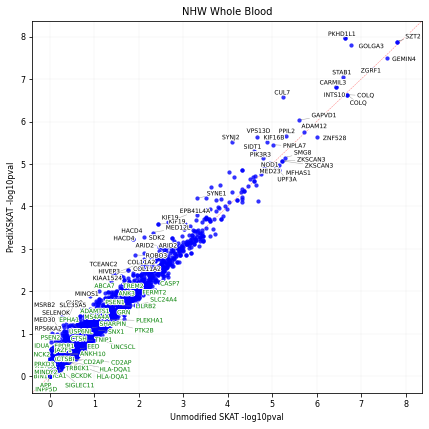

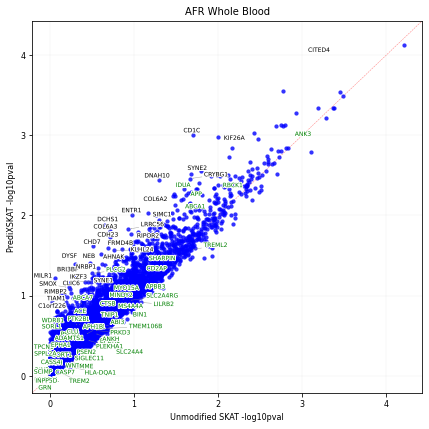

In [38]:
fig1, ax1 = scatters(df1, title='NHW Whole Blood', x_col='log_p1_altall', y_col='log_p1_althiphred', xlabel='All variants -log10pval', ylabel='Phred>20 variants -log10pval')
fig2, ax2 = scatters(df2, title='AFR Whole Blood', x_col='log_p1_altall', y_col='log_p1_althiphred', xlabel='All variants -log10pval', ylabel='Phred>20 variants -log10pval')

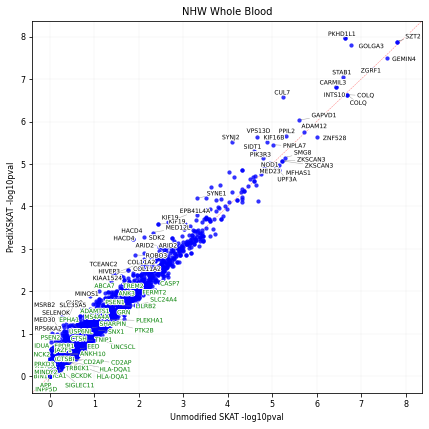

In [41]:
fig1

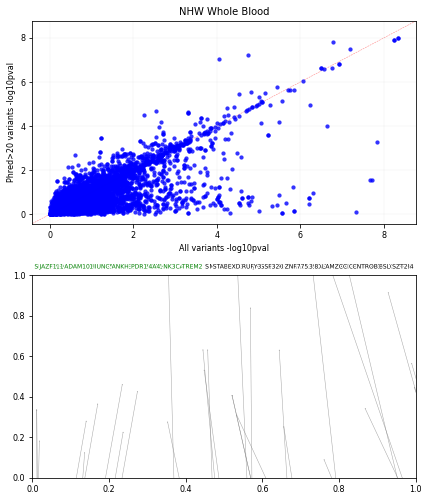

(<Figure size 432x504 with 2 Axes>,
 <AxesSubplot:title={'center':'NHW Whole Blood'}, xlabel='All variants -log10pval', ylabel='Phred>20 variants -log10pval'>)

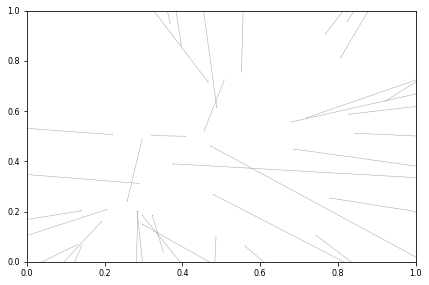

(<Figure size 432x504 with 2 Axes>,
 <AxesSubplot:title={'center':'AFR Whole Blood'}, xlabel='All variants -log10pval', ylabel='Phred>20 variants -log10pval'>)

Text(-0.1, 1.05, 'A')

Text(-0.1, 1.05, 'B')

<Figure size 432x288 with 0 Axes>

In [53]:
fig, axes = plt.subplots(2, 1, figsize=(6, 7))
scatters(df1, title='NHW Whole Blood', ax=axes[0], x_col='log_p1_altall', y_col='log_p1_althiphred', xlabel='All variants -log10pval', ylabel='Phred>20 variants -log10pval')
scatters(df2, title='AFR Whole Blood', ax=axes[1], x_col='log_p1_altall', y_col='log_p1_althiphred', xlabel='All variants -log10pval', ylabel='Phred>20 variants -log10pval')

for ax, label in zip(axes, ['A', 'B']):
    ax.text(-0.1, 1.05, label, transform=ax.transAxes,
            fontsize=12, fontweight='bold', va='top')

plt.tight_layout()
plt.show()
#fig.savefig("fig1.pdf", format="pdf", bbox_inches="tight")

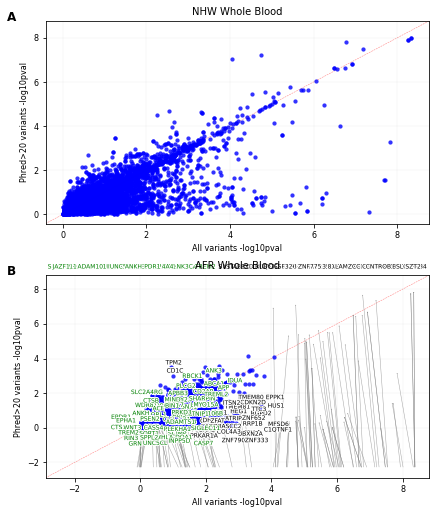

In [54]:
fig